In [ ]:
# =============================================================
# NEONATAL JAUNDICE — FULL PREPROCESSING PIPELINE
# =============================================================
# Confirmed steps (paper-aligned):
#
#  1. Load image (BGR)
#  2. BGR  →  HSV  (colour thresholding to find yellow card)
#  3. Yellow card mask  →  extract card region
#  4. Card region  →  LAB  →  compute mean LAB
#  5. Whole image  →  LAB  →  shift by (ref − card_mean)  (white balance)
#  6. White-balanced LAB  →  BGR  →  RGB  (colour-corrected RGB image)
#  7. Fixed-coordinate ROI crop on RGB image  (skin segmentation)
#  8. RGB ROI  →  HSV      temporal sequence
#  9. RGB ROI  →  YCbCr    temporal sequence
# 10. RGB ROI  →  LAB      temporal sequence
# 11. RGB ROI kept as-is   temporal sequence
# 12. Each sequence stored per image as a row in 4 separate CSV files:
#       pixel_sequences_RGB.csv
#       pixel_sequences_HSV.csv
#       pixel_sequences_YCbCr.csv
#       pixel_sequences_LAB.csv
#     Columns: patient_id | ch1_0 ch1_1 … ch1_N | ch2_0 … | ch3_0 …
#     (one column per channel value per pixel, matching your example format)
# =============================================================

import cv2
import numpy as np
import pandas as pd
import os
import re

# ------------------------------------------------------------
# PATHS — edit for your environment
# ------------------------------------------------------------
IMAGE_FOLDER = "/content/drive/MyDrive/NeoJaundice/NeoJaundice/images"
OUTPUT_FOLDER = "/content/drive/MyDrive/NeoJaundice/temporal_sequences"
IMG_SIZE     = (224, 224)   # resize before any processing
N_PIXELS     = 500          # number of pixels to sample from the ROI

# LAB reference values (OpenCV uint8 LAB encoding):
#   L: 0–255,  a: 0–255 (neutral=128),  b: 0–255 (neutral=128)
# For a standard yellow colour-checker card:
#   L ≈ 180  (bright),  a ≈ 118  (slightly green side),  b ≈ 183  (yellow)
# Adjust if you have measured values from your specific card.
REF_L, REF_A, REF_B = 180.0, 118.0, 183.0


# ------------------------------------------------------------
# HELPER — extract patient id from filename  e.g. "3-2.jpg" → 3
# ------------------------------------------------------------
def get_patient_id(filename):
    match = re.match(r"(\d+)", filename)
    return int(match.group(1)) if match else None


# ============================================================
# STAGE 1 — BGR → HSV → yellow mask → extract card region
# ============================================================
def detect_yellow_card_region(bgr_img):
    """
    Convert BGR image to HSV, apply yellow colour threshold,
    find the largest contour (= calibration card), return BGR crop.

    Pipeline:
        BGR  →  HSV  →  inRange mask  →  morphClose  →
        findContours  →  largest contour  →  boundingRect  →  crop
    """
    # Step: BGR → HSV
    hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)

    # Step: colour thresholding — yellow hue in OpenCV HSV (H: 0–179)
    lower_yellow = np.array([20, 100, 100], dtype=np.uint8)
    upper_yellow = np.array([35, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

    # Step: morphological close to fill small holes in the mask
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Step: find contours of yellow regions
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    # Step: largest contour = yellow reference card
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 200:   # reject tiny noise blobs
        return None

    # Step: crop the card region from the BGR image
    x, y, w, h = cv2.boundingRect(largest)
    return bgr_img[y:y + h, x:x + w]


# ============================================================
# STAGE 2 — White balance: card LAB mean → shift whole image in LAB
# ============================================================
def lab_white_balance(bgr_img):
    """
    1. Detect yellow card crop.
    2. Card crop → LAB → compute mean [L, A, B].
    3. Whole image → LAB (float32).
    4. Shift each channel: img_lab += (REF − card_mean).
    5. Clip → uint8 → LAB → BGR  (white-balanced BGR).

    Returns the white-balanced BGR image.
    If no card found, returns original image unchanged.
    """
    card = detect_yellow_card_region(bgr_img)
    if card is None or card.size == 0:
        return bgr_img   # graceful fallback — no calibration

    # Card → LAB → mean
    card_lab  = cv2.cvtColor(card, cv2.COLOR_BGR2LAB).astype(np.float32)
    card_mean = card_lab.mean(axis=(0, 1))   # [mean_L, mean_A, mean_B]

    # Whole image → LAB
    img_lab = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB).astype(np.float32)

    # Shift all three LAB channels
    img_lab[:, :, 0] += (REF_L - card_mean[0])
    img_lab[:, :, 1] += (REF_A - card_mean[1])
    img_lab[:, :, 2] += (REF_B - card_mean[2])

    img_lab = np.clip(img_lab, 0, 255).astype(np.uint8)

    # Back to BGR (colour-corrected)
    return cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)


# ============================================================
# STAGE 3 — BGR → RGB (colour-corrected RGB base image)
# ============================================================
def bgr_to_rgb(bgr_img):
    return cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)


# ============================================================
# STAGE 4 — Fixed-coordinate ROI crop (skin segmentation)
# ============================================================
def extract_skin_roi(rgb_img, roi_frac=(0.30, 0.70, 0.30, 0.70)):
    """
    Crop a fixed rectangular window from the colour-corrected RGB image.
    This is the paper's "fixed coordinate window" for skin isolation.

    roi_frac = (row_start%, row_end%, col_start%, col_end%)
    Default: centre 40% × 40% of the image.

    Because every image is resized to IMG_SIZE first, the same fractional
    window always maps to the same absolute pixel coordinates.
    Adjust roi_frac to match your specific image capture setup.
    """
    r0, r1, c0, c1 = roi_frac
    h, w = rgb_img.shape[:2]
    return rgb_img[int(h * r0):int(h * r1),
                   int(w * c0):int(w * c1)]


# ============================================================
# STAGE 5 — Convert RGB ROI to each colour space
#           All derived from the same white-balanced RGB ROI
# ============================================================
def rgb_to_hsv(rgb_roi):
    """RGB → HSV via BGR intermediate (OpenCV has no direct RGB→HSV)."""
    bgr = cv2.cvtColor(rgb_roi, cv2.COLOR_RGB2BGR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)          # H:0-179 S:0-255 V:0-255

def rgb_to_ycbcr(rgb_roi):
    """RGB → YCbCr (OpenCV: Y:0-255, Cb:0-255, Cr:0-255)."""
    bgr = cv2.cvtColor(rgb_roi, cv2.COLOR_RGB2BGR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)        # returns Y, Cr, Cb order

def rgb_to_lab(rgb_roi):
    """RGB → LAB (OpenCV uint8: L:0-255, a:0-255, b:0-255)."""
    bgr = cv2.cvtColor(rgb_roi, cv2.COLOR_RGB2BGR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)


# ============================================================
# STAGE 6 — Flatten ROI to pixel sequence (N_PIXELS × 3)
# ============================================================
def roi_to_pixel_sequence(channel_img, n_pixels=N_PIXELS):
    """
    Flatten a (H, W, 3) image to (n_pixels, 3) float32.
    • If total pixels ≥ n_pixels: random sample without replacement.
    • If total pixels < n_pixels: zero-pad at the end.
    Values are kept in their native range (not normalised to [0,1])
    so the CSV values are human-readable (matching your example format).
    """
    pixels = channel_img.reshape(-1, 3).astype(np.float32)

    if len(pixels) >= n_pixels:
        idx    = np.random.choice(len(pixels), n_pixels, replace=False)
        pixels = pixels[idx]
    else:
        pad    = np.zeros((n_pixels - len(pixels), 3), dtype=np.float32)
        pixels = np.concatenate([pixels, pad], axis=0)

    return pixels   # shape (n_pixels, 3)


# ============================================================
# FULL SINGLE-IMAGE PIPELINE
# ============================================================
def process_image(img_path):
    """
    Run the complete preprocessing pipeline on one image.

    Returns a dict:
        {
          'patient_id': int,
          'RGB':   (n_pixels, 3) float32,
          'HSV':   (n_pixels, 3) float32,
          'YCbCr': (n_pixels, 3) float32,
          'LAB':   (n_pixels, 3) float32,
        }
    or None if the image cannot be loaded.
    """
    # ── Load ──────────────────────────────────────────────────
    bgr = cv2.imread(img_path)
    if bgr is None:
        print(f"  [WARN] Cannot load: {img_path}")
        return None

    filename   = os.path.basename(img_path)
    patient_id = get_patient_id(filename)

    # ── Resize (must happen before ROI crop for stable coordinates) ──
    bgr = cv2.resize(bgr, IMG_SIZE, interpolation=cv2.INTER_AREA)

    # ── Stage 1+2: BGR → HSV thresholding → yellow card mask
    #               → card LAB mean → shift image in LAB → white-balanced BGR ──
    bgr_wb = lab_white_balance(bgr)

    # ── Stage 3: White-balanced BGR → RGB ──────────────────────
    rgb_wb = bgr_to_rgb(bgr_wb)

    # ── Stage 4: Fixed-coordinate skin ROI on RGB image ────────
    rgb_roi = extract_skin_roi(rgb_wb)
    if rgb_roi.size == 0:
        print(f"  [WARN] Empty ROI: {img_path}")
        return None

    # ── Stage 5: RGB ROI → all colour spaces ───────────────────
    hsv_roi   = rgb_to_hsv(rgb_roi)
    ycbcr_roi = rgb_to_ycbcr(rgb_roi)
    lab_roi   = rgb_to_lab(rgb_roi)

    # ── Stage 6: Flatten each to (N_PIXELS, 3) ─────────────────
    return {
        "patient_id": patient_id,
        "RGB":   roi_to_pixel_sequence(rgb_roi),
        "HSV":   roi_to_pixel_sequence(hsv_roi),
        "YCbCr": roi_to_pixel_sequence(ycbcr_roi),
        "LAB":   roi_to_pixel_sequence(lab_roi),
    }


# ============================================================
# BUILD AND SAVE CSV FILES
# ============================================================
def build_and_save_all(image_folder, output_folder):
    """
    Process every image in image_folder.
    Save 4 CSV files (one per colour space) to output_folder.

    CSV format (one row = one image):
        patient_id | ch1_0  ch1_1 … ch1_{N-1} | ch2_0 … | ch3_0 …

    For HSV this becomes:
        patient_id | H_0  H_1 … H_499 | S_0 … S_499 | V_0 … V_499

    This matches your requested format:
        patient_id    H             S             V
        1             16.059...     121.878...    169.491...
    (each pixel gets its own column — H_0, H_1, … S_0, S_1 … V_0, V_1 …)
    """
    os.makedirs(output_folder, exist_ok=True)

    # Channel name maps
    channel_names = {
        "RGB":   ("R", "G", "B"),
        "HSV":   ("H", "S", "V"),
        "YCbCr": ("Y", "Cb", "Cr"),
        "LAB":   ("L", "A", "B"),
    }

    # Accumulators
    records = {cs: [] for cs in channel_names}

    image_files = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"Found {len(image_files)} images in {image_folder}")

    for i, fname in enumerate(image_files, 1):
        path   = os.path.join(image_folder, fname)
        result = process_image(path)

        if result is None:
            continue

        pid = result["patient_id"]

        for cs, (c1, c2, c3) in channel_names.items():
            seq = result[cs]   # (N_PIXELS, 3)

            row = {"patient_id": pid, "image_name": fname}
            # Store each pixel value as its own column: H_0, H_1, …
            for pix_idx in range(N_PIXELS):
                row[f"{c1}_{pix_idx}"] = seq[pix_idx, 0]
                row[f"{c2}_{pix_idx}"] = seq[pix_idx, 1]
                row[f"{c3}_{pix_idx}"] = seq[pix_idx, 2]

            records[cs].append(row)

        if i % 20 == 0:
            print(f"  Processed {i}/{len(image_files)} images…")

    # Save one CSV per colour space
    for cs in channel_names:
        df  = pd.DataFrame(records[cs])
        out = os.path.join(output_folder, f"pixel_sequences_{cs}.csv")
        df.to_csv(out, index=False)
        print(f"  Saved {cs} → {out}  ({len(df)} rows, {len(df.columns)} columns)")

    print("\n✅ All 4 temporal sequence CSVs saved.")
    return records


# ============================================================
# ENTRY POINT
# ============================================================
if __name__ == "__main__":
    # Mount Google Drive if running in Colab
    if not os.path.exists(IMAGE_FOLDER):
        try:
            from google.colab import drive
            drive.mount("/content/drive", force_remount=True)
        except ImportError:
            pass

    if not os.path.exists(IMAGE_FOLDER):
        raise FileNotFoundError(f"Image folder not found: {IMAGE_FOLDER}")

    records = build_and_save_all(IMAGE_FOLDER, OUTPUT_FOLDER)

    # ── Quick sanity check — print first row of each CSV ──────
    print("\n── Sample row (first image, first 3 pixels of each channel) ──")
    for cs in ("RGB", "HSV", "YCbCr", "LAB"):
        if records[cs]:
            row   = records[cs][0]
            cnames = {"RGB":("R","G","B"), "HSV":("H","S","V"),
                      "YCbCr":("Y","Cb","Cr"), "LAB":("L","A","B")}
            c1, c2, c3 = cnames[cs]
            print(f"\n{cs}  patient_id={row['patient_id']}  image={row['image_name']}")
            print(f"  {c1}_0={row[f'{c1}_0']:.4f}  {c1}_1={row[f'{c1}_1']:.4f}")
            print(f"  {c2}_0={row[f'{c2}_0']:.4f}  {c2}_1={row[f'{c2}_1']:.4f}")
            print(f"  {c3}_0={row[f'{c3}_0']:.4f}  {c3}_1={row[f'{c3}_1']:.4f}")


Mounted at /content/drive
Found 2235 images in /content/drive/MyDrive/NeoJaundice/NeoJaundice/images
  Processed 20/2235 images…
  Processed 40/2235 images…
  Processed 60/2235 images…
  Processed 80/2235 images…
  Processed 100/2235 images…
  Processed 120/2235 images…
  Processed 140/2235 images…
  Processed 160/2235 images…
  Processed 180/2235 images…
  Processed 200/2235 images…
  Processed 220/2235 images…
  Processed 240/2235 images…
  Processed 260/2235 images…
  Processed 280/2235 images…
  Processed 300/2235 images…
  Processed 320/2235 images…
  Processed 340/2235 images…
  Processed 360/2235 images…
  Processed 380/2235 images…
  Processed 400/2235 images…
  Processed 420/2235 images…
  Processed 440/2235 images…
  Processed 460/2235 images…
  Processed 480/2235 images…
  Processed 500/2235 images…
  Processed 520/2235 images…
  Processed 540/2235 images…
  Processed 560/2235 images…
  Processed 580/2235 images…
  Processed 600/2235 images…
  Processed 620/2235 images…
  Pr

In [ ]:


# ─────────────────────────────────────────────────────────────
# CONFIGURATION  ← edit here, nowhere else
# ─────────────────────────────────────────────────────────────

# Stream A colour space  (RGB | HSV | YCbCr | LAB)
STREAM_A = "RGB"
# Stream B colour space
STREAM_B = "HSV"

# Google Drive paths to the two temporal sequence CSVs
# (produced by preprocessing_final.py)
CSV_A = "/content/drive/MyDrive/NeoJaundice/temporal_sequences/pixel_sequences_RGB.csv"
CSV_B = "/content/drive/MyDrive/NeoJaundice/temporal_sequences/pixel_sequences_HSV.csv"

LABELS_CSV = "/content/drive/MyDrive/NeoJaundice/NeoJaundice/labels.csv"

# Output
OUTPUT_DIR = "/content/drive/MyDrive/NeoJaundice/results"
MODEL_NAME = f"dual_{STREAM_A}_{STREAM_B}"
OUTPUT_CSV = os.path.join(OUTPUT_DIR, f"predictions_{MODEL_NAME}.csv")
MODEL_PATH = os.path.join(OUTPUT_DIR, f"model_{MODEL_NAME}.keras")

# ── Split percentages (must sum to 1.0) ──────────────────────
TRAIN_FRAC = 0.70    # 70 %
VAL_FRAC   = 0.10    # 10 %
TEST_FRAC  = 0.20    # 20 %
# How to change:
#   60/20/20 → TRAIN_FRAC=0.60, VAL_FRAC=0.20, TEST_FRAC=0.20
#   80/10/10 → TRAIN_FRAC=0.80, VAL_FRAC=0.10, TEST_FRAC=0.10

# ── Model / training ─────────────────────────────────────────
N_PIXELS    = 500
N_CHANNELS  = 3
BATCH_SIZE  = 32
MAX_EPOCHS  = 150
LR_INIT     = 0.001
RANDOM_SEED = 42

# ─────────────────────────────────────────────────────────────
# HELPER — load temporal sequence CSV → (N, 500, 3) array
# ─────────────────────────────────────────────────────────────
CHANNEL_MAP = {
    "RGB":   ("R",  "G",  "B"),
    "HSV":   ("H",  "S",  "V"),
    "YCbCr": ("Y",  "Cb", "Cr"),
    "LAB":   ("L",  "A",  "B"),
}

def load_sequences(csv_path, color_space, n_pixels=N_PIXELS):
    """
    Read pixel sequence CSV.
    Returns X (N, n_pixels, 3), patient_ids list, image_names list.
    """
    df = pd.read_csv(csv_path)
    c1, c2, c3 = CHANNEL_MAP[color_space]

    ch1 = df[[f"{c1}_{i}" for i in range(n_pixels)]].values.astype(np.float32)
    ch2 = df[[f"{c2}_{i}" for i in range(n_pixels)]].values.astype(np.float32)
    ch3 = df[[f"{c3}_{i}" for i in range(n_pixels)]].values.astype(np.float32)

    X = np.stack([ch1, ch2, ch3], axis=-1)    # (N, 500, 3)
    return X, df["patient_id"].tolist(), df["image_name"].tolist()


# ─────────────────────────────────────────────────────────────
# BUILD SINGLE CNN BRANCH  (shared architecture, Table 2)
# Returns the feature vector (Flatten output) from one stream.
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dense,
    Dropout,
    Concatenate,
    BatchNormalization,
    GlobalAveragePooling1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


def build_cnn_branch(inp_tensor, name_prefix):

    x = Conv1D(
        32,
        kernel_size=3,
        padding="same",
        kernel_regularizer=l2(1e-4),
        name=f"{name_prefix}_conv1"
    )(inp_tensor)

    x = BatchNormalization()(x)
    x = MaxPooling1D(
        pool_size=2,
        padding="same",
        name=f"{name_prefix}_pool1"
    )(x)

    x = Conv1D(
        64,
        kernel_size=3,
        padding="same",
        kernel_regularizer=l2(1e-4),
        name=f"{name_prefix}_conv2"
    )(x)

    x = BatchNormalization()(x)
    x = MaxPooling1D(
        pool_size=2,
        padding="same",
        name=f"{name_prefix}_pool2"
    )(x)

    x = Conv1D(
        128,
        kernel_size=3,
        padding="same",
        kernel_regularizer=l2(1e-4),
        name=f"{name_prefix}_conv3"
    )(x)

    x = BatchNormalization()(x)
    x = MaxPooling1D(
        pool_size=2,
        padding="same",
        name=f"{name_prefix}_pool3"
    )(x)

    x = Conv1D(
        128,
        kernel_size=3,
        padding="same",
        kernel_regularizer=l2(1e-4),
        name=f"{name_prefix}_conv4"
    )(x)

    x = BatchNormalization()(x)
    x = MaxPooling1D(
        pool_size=2,
        padding="same",
        name=f"{name_prefix}_pool4"
    )(x)

    x = GlobalAveragePooling1D(
        name=f"{name_prefix}_gap"
    )(x)

    return x


def build_dual_1dcnn(
    input_shape=(N_PIXELS, N_CHANNELS)
):

    inp_a = Input(
        shape=input_shape,
        name=f"input_{STREAM_A}"
    )

    feat_a = build_cnn_branch(
        inp_a,
        name_prefix=STREAM_A
    )

    inp_b = Input(
        shape=input_shape,
        name=f"input_{STREAM_B}"
    )

    feat_b = build_cnn_branch(
        inp_b,
        name_prefix=STREAM_B
    )

    merged = Concatenate(
        name="concatenate"
    )([feat_a, feat_b])

    x = Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-4),
        name="dense1"
    )(merged)

    x = Dropout(
        0.4,
        name="drop1"
    )(x)

    x = Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(1e-4),
        name="dense2"
    )(x)

    x = Dropout(
        0.6,
        name="drop2"
    )(x)

    out = Dense(
        1,
        activation="linear",
        name="output"
    )(x)

    model = Model(
        inputs=[inp_a, inp_b],
        outputs=out,
        name=f"DualCNN_{STREAM_A}_{STREAM_B}"
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

# ─────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # ── 0. Mount Drive if needed ─────────────────────────────
    for p in [CSV_A, CSV_B]:
        if not os.path.exists(p):
            try:
                from google.colab import drive
                drive.mount("/content/drive", force_remount=True)
            except ImportError:
                pass
            break
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ── 1. Load both streams ──────────────────────────────────
    print(f"Loading stream A ({STREAM_A}) from:\n  {CSV_A}")
    Xa, pids_a, names_a = load_sequences(CSV_A, STREAM_A)

    print(f"Loading stream B ({STREAM_B}) from:\n  {CSV_B}")
    Xb, pids_b, names_b = load_sequences(CSV_B, STREAM_B)

    # Sanity check: both CSVs must have the same images in the same order
    assert names_a == names_b, (
        "Stream A and B CSVs contain different images or different ordering.\n"
        "Re-run preprocessing_final.py to regenerate both from the same source."
    )
    print(f"  Xa: {Xa.shape}  |  Xb: {Xb.shape}")

    # ── 2. Load labels ────────────────────────────────────────
    labels_df = pd.read_csv(LABELS_CSV)
    label_map = dict(zip(labels_df["image_idx"], labels_df["blood(mg/dL)"]))
    y = np.array([label_map[name] for name in names_a], dtype=np.float32)
    print(f"  y shape: {y.shape}  |  range [{y.min():.2f}, {y.max():.2f}]")

    # ── 3. Split ──────────────────────────────────────────────
    assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-6, \
        "TRAIN_FRAC + VAL_FRAC + TEST_FRAC must equal 1.0"

    indices = np.arange(len(y))
    idx_tv, idx_test = train_test_split(
        indices, test_size=TEST_FRAC, random_state=RANDOM_SEED)
    val_frac_of_tv = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)
    idx_train, idx_val = train_test_split(
        idx_tv, test_size=val_frac_of_tv, random_state=RANDOM_SEED)

    # Split both streams with identical index arrays
    Xa_train, Xa_val, Xa_test = Xa[idx_train], Xa[idx_val], Xa[idx_test]
    Xb_train, Xb_val, Xb_test = Xb[idx_train], Xb[idx_val], Xb[idx_test]
    y_train,  y_val,  y_test  =  y[idx_train],  y[idx_val],  y[idx_test]

    print(f"\nSplit  →  train: {len(y_train)}  |  val: {len(y_val)}  |  test: {len(y_test)}")
    print(f"         ({TRAIN_FRAC*100:.0f}% / {VAL_FRAC*100:.0f}% / {TEST_FRAC*100:.0f}%)")

    # ── 4. Build model ────────────────────────────────────────
    model = build_dual_1dcnn(input_shape=(N_PIXELS, N_CHANNELS))
    model.summary()

    # ── 5. Callbacks ─────────────────────────────────────────
  callbaxks=[
   early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
  ]
    # ── 6. Train ──────────────────────────────────────────────
    print(f"\nTraining dual-stream {STREAM_A}+{STREAM_B} model …")
    history = model.fit(
        [Xa_train, Xb_train], y_train,       # ← list of two inputs
        validation_data=([Xa_val, Xb_val], y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    # ── 7. Evaluate ───────────────────────────────────────────
    y_pred = model.predict([Xa_test, Xb_test], verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"\n── Test results ({STREAM_A}+{STREAM_B}) ────────────────")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

    # ── 8. Save predictions CSV ───────────────────────────────
    pids_test  = [pids_a[i]  for i in idx_test]
    names_test = [names_a[i] for i in idx_test]

    out_df = pd.DataFrame({
        "patient_id":          pids_test,
        "image_name":          names_test,
        "actual_bilirubin":    y_test,
        "predicted_bilirubin": np.round(y_pred, 4),
    })
    out_df.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✅ Predictions saved → {OUTPUT_CSV}")
    print(out_df.head(10).to_string(index=False))

    # ── 9. Append to shared metrics summary ──────────────────
    metrics_path = os.path.join(OUTPUT_DIR, "metrics_summary.csv")
    metrics_row = pd.DataFrame([{
        "model":       MODEL_NAME,
        "color_space": f"{STREAM_A}+{STREAM_B}",
        "RMSE":  round(rmse, 4),
        "MAE":   round(mae,  4),
        "R2":    round(r2,   4),
        "train_n": len(y_train),
        "val_n":   len(y_val),
        "test_n":  len(y_test),
    }])
    if os.path.exists(metrics_path):
        existing = pd.read_csv(metrics_path)
        metrics_row = pd.concat([existing, metrics_row], ignore_index=True)
    metrics_row.to_csv(metrics_path, index=False)
    print(f"   Metrics appended → {metrics_path}")

Loading stream A (RGB) from:
  /content/drive/MyDrive/NeoJaundice/temporal_sequences/pixel_sequences_RGB.csv
Loading stream B (HSV) from:
  /content/drive/MyDrive/NeoJaundice/temporal_sequences/pixel_sequences_HSV.csv
  Xa: (2235, 500, 3)  |  Xb: (2235, 500, 3)
  y shape: (2235,)  |  range [0.00, 25.70]

Split  →  train: 1564  |  val: 224  |  test: 447
         (70% / 10% / 20%)


Model: "DualCNN_RGB_HSV"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_RGB           │ (None, 500, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_HSV           │ (None, 500, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_conv1 (Conv1D)  │ (None, 500, 32)   │        320 │ input_RGB[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_conv1 (Conv1D)  │ (None, 500, 32)   │        320 │ input_HSV[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_pool1           │ (None, 250, 32)   │          0 │ RGB_conv1[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_pool1           │ (None, 250, 32)   │          0 │ HSV_conv1[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_conv2 (Conv1D)  │ (None, 250, 64)   │      6,208 │ RGB_pool1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_conv2 (Conv1D)  │ (None, 250, 64)   │      6,208 │ HSV_pool1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_pool2           │ (None, 125, 64)   │          0 │ RGB_conv2[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_pool2           │ (None, 125, 64)   │          0 │ HSV_conv2[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_conv3 (Conv1D)  │ (None, 125, 128)  │     24,704 │ RGB_pool2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_conv3 (Conv1D)  │ (None, 125, 128)  │     24,704 │ HSV_pool2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_pool3           │ (None, 63, 128)   │          0 │ RGB_conv3[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_pool3           │ (None, 63, 128)   │          0 │ HSV_conv3[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_conv4 (Conv1D)  │ (None, 63, 128)   │     49,280 │ RGB_pool3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_conv4 (Conv1D)  │ (None, 63, 128)   │     49,280 │ HSV_pool3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_pool4           │ (None, 32, 128)   │          0 │ RGB_conv4[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_pool4           │ (None, 32, 128)   │          0 │ HSV_conv4[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_flatten         │ (None, 4096)      │          0 │ RGB_pool4[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,291,457 (8.74 MB)

 Trainable params: 2,291,457 (8.74 MB)

 Non-trainable params: 0 (0.00 B)


Training dual-stream RGB+HSV model …
Epoch 1/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - loss: 22829.3027 - mae: 33.8153 - val_loss: 27.4875 - val_mae: 4.2278 - learning_rate: 0.0100
Epoch 2/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 48.2497 - mae: 5.6841 - val_loss: 34.3931 - val_mae: 4.9648 - learning_rate: 0.0100
Epoch 3/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - loss: 38.3815 - mae: 5.1455 - val_loss: 56.9221 - val_mae: 6.5004 - learning_rate: 0.0100
Epoch 4/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - loss: 35.6112 - mae: 4.8927 - val_loss: 26.7751 - val_mae: 4.3160 - learning_rate: 0.0100
Epoch 5/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - loss: 38.2732 - mae: 5.0633 - val_loss: 38.6670 - val_mae: 5.3143 - learning_rate: 0.0100
Epoch 6/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - loss: 116.0520 - mae: 6.5223 - val_loss: 162.2464 - val_mae: 11.6234 - learning_rate: 0.0100
Epoch 7/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - loss: 314.4426 - mae: 10.664

In [ ]:
# =============================================================
# MODEL 1 — SINGLE-STREAM 1DCNN  (paper Table 2 + Table 4)
# =============================================================
# Architecture (Table 2):
#   Conv1D(32,  k=3, same, ReLU) → MaxPool(2, same)
#   Conv1D(64,  k=3, same, ReLU) → MaxPool(2, same)
#   Conv1D(128, k=3, same, ReLU) → MaxPool(2, same)
#   Conv1D(128, k=3, same, ReLU) → MaxPool(2, same)
#   Flatten
#   Dense(256, ReLU) → Dropout(0.3)
#   Dense(128, ReLU) → Dropout(0.5)
#   Dense(1, linear)                      ← regression output
#
# Hyperparameters (Table 4):
#   Optimizer : Adam, lr = 0.01 decayed via ReduceLROnPlateau
#   Loss : MSE   |   Batch : 32   |   Epochs : 150 + EarlyStopping
#
# ── HOW THE 3-IMAGES-PER-PATIENT LOGIC WORKS ──────────────────
# The NeoJaundice dataset has 2235 images of 745 infants.
# Each infant has exactly 3 images (head, face, chest).
# All 3 images of the same infant share the same TSB label.
#
# The paper (Table 3) treats EACH IMAGE as an independent
# training sample — the model learns from 2235 rows, not 745.
# This is correct because every image gives the 1DCNN a
# different view (different body region) of the same bilirubin
# level, effectively tripling the training data.
#
# However, the 3 images of one patient MUST all stay in the
# same split (train / val / test).  Mixing them across splits
# causes data leakage — the model trains on one view of a baby
# and is tested on another view of the SAME baby.
#
# FIX — patient-level split:
#   1. Shuffle UNIQUE patient IDs.
#   2. Assign patient IDs to train / val / test by count.
#   3. Collect ALL image rows belonging to each patient group.
#   → Every image is still an independent sample (paper intent).
#   → No patient ever crosses a split boundary (no leakage).
#
# This matches Table 3 exactly:
#   745 × 70% = 521 patients → 521 × 3 = 1563 ≈ 1564 train imgs
#   745 × 10% =  75 patients →  75 × 3 =  225 ≈  224 val   imgs
#   745 × 20% = 149 patients → 149 × 3 =  447 =   447 test  imgs
#
# ── HOW TO CONTROL SPLITS ─────────────────────────────────────
# Edit the three lines below TRAIN_FRAC / VAL_FRAC / TEST_FRAC.
# They must sum to 1.0.  Example:
#   60 / 20 / 20  →  TRAIN_FRAC=0.60, VAL_FRAC=0.20, TEST_FRAC=0.20
#   80 / 10 / 10  →  TRAIN_FRAC=0.80, VAL_FRAC=0.10, TEST_FRAC=0.10
#
# ── HOW TO SWITCH COLOUR SPACE ────────────────────────────────
# Edit COLOR_SPACE and CSV_PATH at the top of CONFIGURATION.
# =============================================================


COLOR_SPACE = "YCbCr"

# CSV produced by preprocessing_final.py for the chosen colour space
CSV_PATH   = "/content/drive/MyDrive/NeoJaundice/temporal_sequences/pixel_sequences_YCbCr.csv"

# Labels CSV — must contain columns: image_idx, blood(mg/dL)
LABELS_CSV = "/content/drive/MyDrive/NeoJaundice/NeoJaundice/labels.csv"

# Output folder
OUTPUT_DIR = "/content/drive/MyDrive/NeoJaundice/results"

# ── Split control (patient-level, must sum to 1.0) ────────────
TRAIN_FRAC = 0.80   # 70 % of patients  →  training images
VAL_FRAC   = 0.10   # 10 % of patients  →  validation images
TEST_FRAC  = 0.10   # 20 % of patients  →  test images

# ── Model / training knobs ────────────────────────────────────
N_PIXELS    = 500   # pixels per image — must match preprocessing
N_CHANNELS  = 3     # channels per pixel (R+G+B or H+S+V etc.)
BATCH_SIZE  = 32
MAX_EPOCHS  = 150
LR_INIT     = 0.001
RANDOM_SEED = 42

# ─────────────────────────────────────────────────────────────
# CHANNEL MAP
# ─────────────────────────────────────────────────────────────
CHANNEL_MAP = {
    "RGB":   ("R",  "G",  "B"),
    "HSV":   ("H",  "S",  "V"),
    "YCbCr": ("Y",  "Cb", "Cr"),
    "LAB":   ("L",  "A",  "B"),
}


# ─────────────────────────────────────────────────────────────
# LOAD SEQUENCES
# ─────────────────────────────────────────────────────────────
def load_sequences(csv_path, color_space, n_pixels=N_PIXELS):
    """
    Read the temporal sequence CSV and reconstruct the 3-D array.

    Each row in the CSV is ONE image → ONE training sample.
    Three consecutive rows belong to the same patient (same TSB).

    Returns
    -------
    X           : (N, n_pixels, 3)  float32
    patient_ids : list[int], length N — repeats 3× per patient
    image_names : list[str], length N
    """
    df = pd.read_csv(csv_path)
    c1, c2, c3 = CHANNEL_MAP[color_space]

    ch1 = df[[f"{c1}_{i}" for i in range(n_pixels)]].values.astype(np.float32)
    ch2 = df[[f"{c2}_{i}" for i in range(n_pixels)]].values.astype(np.float32)
    ch3 = df[[f"{c3}_{i}" for i in range(n_pixels)]].values.astype(np.float32)

    # Stack: (N, n_pixels, 3) — each pixel is a timestep with 3 channel values
    X = np.stack([ch1, ch2, ch3], axis=-1)
    return X, df["patient_id"].tolist(), df["image_name"].tolist()


# ─────────────────────────────────────────────────────────────
# PATIENT-LEVEL SPLIT
# ─────────────────────────────────────────────────────────────
def patient_level_split(patient_ids, train_frac, val_frac, test_frac,
                        random_seed=42):
    """
    Split image-row indices so that ALL 3 images of every patient
    land in exactly ONE split (train / val / test).

    Why this is needed
    ------------------
    The 3 images of a patient share the same label.  If they land
    in different splits the model is evaluated on data it has
    indirectly seen during training → inflated metrics.

    How it works
    ------------
    1. Shuffle unique patient IDs with a fixed seed.
    2. Slice the shuffled list into train / val / test by patient count.
    3. Map each patient group back to its image row indices.

    Parameters
    ----------
    patient_ids : list — patient_id value for every image row
    train_frac, val_frac, test_frac : float  (must sum to 1.0)

    Returns
    -------
    idx_train, idx_val, idx_test : numpy int arrays of row indices
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6, \
        "TRAIN_FRAC + VAL_FRAC + TEST_FRAC must equal 1.0"

    # Step 1 — shuffle unique patients
    unique_pats = np.array(sorted(set(patient_ids)))
    rng = np.random.RandomState(random_seed)
    rng.shuffle(unique_pats)

    # Step 2 — slice by patient count
    n       = len(unique_pats)
    n_test  = max(1, round(n * test_frac))
    n_val   = max(1, round(n * val_frac))
    n_train = n - n_test - n_val

    pat_train = set(unique_pats[:n_train])
    pat_val   = set(unique_pats[n_train : n_train + n_val])
    pat_test  = set(unique_pats[n_train + n_val :])

    # Step 3 — collect image row indices per patient group
    pid_arr   = np.array(patient_ids)
    idx_train = np.where(np.isin(pid_arr, list(pat_train)))[0]
    idx_val   = np.where(np.isin(pid_arr, list(pat_val)))[0]
    idx_test  = np.where(np.isin(pid_arr, list(pat_test)))[0]

    return idx_train, idx_val, idx_test


# ─────────────────────────────────────────────────────────────
# BUILD MODEL  (Table 2)
# ─────────────────────────────────────────────────────────────
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
import tensorflow as tf


def build_single_model():

    inp = layers.Input(
        shape=(N_CHANNELS, N_PIXELS)
    )

    x = layers.Conv1D(
        32,
        3,
        padding="same",
        kernel_regularizer=l2(1e-4)
    )(inp)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(
        2,
        padding="same"
    )(x)

    x = layers.Conv1D(
        64,
        3,
        padding="same",
        kernel_regularizer=l2(1e-4)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(
        2,
        padding="same"
    )(x)

    x = layers.Conv1D(
        128,
        3,
        padding="same",
        kernel_regularizer=l2(1e-4)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(
        2,
        padding="same"
    )(x)

    x = layers.Conv1D(
        128,
        3,
        padding="same",
        kernel_regularizer=l2(1e-4)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(
        2,
        padding="same"
    )(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    )(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    )(x)

    x = layers.Dropout(0.6)(x)

    out = layers.Dense(
        1,
        activation="linear"
    )(x)

    model = models.Model(
        inp,
        out
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


# ─────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # ── 0. Mount Drive (Colab) ───────────────────────────────
    if not os.path.exists(CSV_PATH):
        try:
            from google.colab import drive
            drive.mount("/content/drive", force_remount=True)
        except ImportError:
            pass
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    OUTPUT_CSV  = os.path.join(OUTPUT_DIR, f"predictions_{COLOR_SPACE}_single.csv")
    MODEL_PATH  = os.path.join(OUTPUT_DIR, f"model_{COLOR_SPACE}_single.keras")
    METRICS_CSV = os.path.join(OUTPUT_DIR, "metrics_summary.csv")

    # ── 1. Load temporal sequences ───────────────────────────
    print(f"\nLoading {COLOR_SPACE} sequences …")
    X, patient_ids, image_names = load_sequences(CSV_PATH, COLOR_SPACE)
    print(f"  Total images  : {len(X)}")
    print(f"  Unique patients: {len(set(patient_ids))}")
    print(f"  X shape        : {X.shape}  (images × pixels × channels)")

    # ── 2. Load labels aligned to image rows ─────────────────
    labels_df = pd.read_csv(LABELS_CSV)
    label_map = dict(zip(labels_df["image_idx"], labels_df["blood(mg/dL)"]))
    y = np.array([label_map[name] for name in image_names], dtype=np.float32)
    print(f"  Label range    : [{y.min():.2f}, {y.max():.2f}] mg/dL")

    # ── 3. Patient-level split ───────────────────────────────
    # Fraction validation happens inside patient_level_split().
    print(f"\nSplitting by patient  "
          f"({TRAIN_FRAC*100:.0f} / {VAL_FRAC*100:.0f} / {TEST_FRAC*100:.0f} %) …")

    idx_train, idx_val, idx_test = patient_level_split(
        patient_ids, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, RANDOM_SEED)

    pid_arr    = np.array(patient_ids)
    train_pats = set(pid_arr[idx_train])
    val_pats   = set(pid_arr[idx_val])
    test_pats  = set(pid_arr[idx_test])

    # Hard check — zero patient overlap
    assert not (train_pats & test_pats), "LEAK: patient in train AND test"
    assert not (train_pats & val_pats),  "LEAK: patient in train AND val"
    assert not (val_pats   & test_pats), "LEAK: patient in val AND test"

    print(f"  Train : {len(idx_train):4d} images  ({len(train_pats)} patients)")
    print(f"  Val   : {len(idx_val):4d} images  ({len(val_pats)} patients)")
    print(f"  Test  : {len(idx_test):4d} images  ({len(test_pats)} patients)")
    print(f"  ✓ Zero patient overlap confirmed")

    X_train, y_train = X[idx_train], y[idx_train]
    X_val,   y_val   = X[idx_val],   y[idx_val]
    X_test,  y_test  = X[idx_test],  y[idx_test]

    # ── 4. Build model ────────────────────────────────────────
    model = build_1dcnn(input_shape=(N_PIXELS, N_CHANNELS))
    model.summary()

    # ── 5. Callbacks (Table 4) ────────────────────────────────
    callbacks = [
       early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)
    ]

    # ── 6. Train ─────────────────────────────────────────────
    print(f"\nTraining {COLOR_SPACE} single-stream model …")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    # ── 7. Evaluate on test set ───────────────────────────────
    y_pred = model.predict(X_test, verbose=0).flatten()
    y_pred = np.clip(y_pred, 0, None)   # bilirubin cannot be negative

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"\n── Test results  ({COLOR_SPACE} single-stream) ──────────")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

    # ── 8. Save predictions CSV ───────────────────────────────
    out_df = pd.DataFrame({
        "patient_id":          [patient_ids[i] for i in idx_test],
        "image_name":          [image_names[i] for i in idx_test],
        "actual_bilirubin":    np.round(y_test,  4),
        "predicted_bilirubin": np.round(y_pred,  4),
    })
    out_df.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✅ Predictions saved → {OUTPUT_CSV}")
    print(out_df.head(10).to_string(index=False))

    # ── 9. Append metrics summary ─────────────────────────────
    new_row = pd.DataFrame([{
        "model":           f"single_{COLOR_SPACE}",
        "color_space":     COLOR_SPACE,
        "split_type":      "patient-level",
        "train_frac":      TRAIN_FRAC,
        "val_frac":        VAL_FRAC,
        "test_frac":       TEST_FRAC,
        "train_images":    len(idx_train),
        "val_images":      len(idx_val),
        "test_images":     len(idx_test),
        "train_patients":  len(train_pats),
        "val_patients":    len(val_pats),
        "test_patients":   len(test_pats),
        "RMSE":            round(rmse, 4),
        "MAE":             round(mae,  4),
        "R2":              round(r2,   4),
    }])
    if os.path.exists(METRICS_CSV):
        new_row = pd.concat([pd.read_csv(METRICS_CSV), new_row],
                            ignore_index=True)
    new_row.to_csv(METRICS_CSV, index=False)
    print(f"   Metrics appended → {METRICS_CSV}")




Loading YCbCr sequences …
  Total images  : 2235
  Unique patients: 745
  X shape        : (2235, 500, 3)  (images × pixels × channels)
  Label range    : [0.00, 25.70] mg/dL

Splitting by patient  (80 / 10 / 10 %) …
  Train : 1791 images  (597 patients)
  Val   :  222 images  (74 patients)
  Test  :  222 images  (74 patients)
  ✓ Zero patient overlap confirmed


Model: "1DCNN_single_YCbCr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 500, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 500, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 250, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 125, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 63, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling1D)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,162,369 (4.43 MB)

 Trainable params: 1,162,369 (4.43 MB)

 Non-trainable params: 0 (0.00 B)


Training YCbCr single-stream model …
Epoch 1/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 5202.1597 - mae: 18.3138 - val_loss: 31.1063 - val_mae: 4.7784 - learning_rate: 0.0100
Epoch 2/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 41.3237 - mae: 5.3068 - val_loss: 33.9362 - val_mae: 5.1476 - learning_rate: 0.0100
Epoch 3/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 42.3195 - mae: 5.3390 - val_loss: 31.3451 - val_mae: 4.8788 - learning_rate: 0.0100
Epoch 4/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 40.5754 - mae: 5.2746 - val_loss: 31.1629 - val_mae: 4.6496 - learning_rate: 0.0100
Epoch 5/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 39.4248 - mae: 5.1454 - val_loss: 31.4672 - val_mae: 4.9128 - learning_rate: 0.0100
Epoch 6/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 36.2697 - mae: 4.9782 - val_loss: 36.0250 - val_mae: 5.3087 - learning_rate: 0.0100
Epoch 7/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 37.4481 - mae: 5.0381 - val_loss: 4


── Test results  (YCbCr single-stream) ──────────
  RMSE : 3.7690
  MAE  : 3.0822
  R²   : 0.4257

✅ Predictions saved → /content/drive/MyDrive/NeoJaundice/results/predictions_YCbCr_single.csv
 patient_id image_name  actual_bilirubin  predicted_bilirubin
          2 0002-1.jpg              11.9               9.7264
          2 0002-2.jpg              11.9              15.4497
          2 0002-3.jpg              11.9              13.6167
         16 0016-1.jpg               4.9              12.8339
         16 0016-2.jpg               4.9               9.0359
         16 0016-3.jpg               4.9              11.1675
         33 0033-1.jpg              12.7              13.7267
         33 0033-2.jpg              12.7              14.1168
         33 0033-3.jpg              12.7              12.9443
         35 0035-1.jpg              12.2              12.9430
   Metrics appended → /content/drive/MyDrive/NeoJaundice/results/metrics_summary.csv


In [ ]:
# =============================================================
# MODEL 2 — DUAL-STREAM 1DCNN  (paper Fig. 3 + Table 2 + Table 4)
# =============================================================
# Architecture (Fig. 3):
#   Stream A (e.g. RGB):
#     Conv1D(32)→Pool → Conv1D(64)→Pool →
#     Conv1D(128)→Pool → Conv1D(128)→Pool → Flatten = Features_A
#
#   Stream B (e.g. HSV):
#     Conv1D(32)→Pool → Conv1D(64)→Pool →
#     Conv1D(128)→Pool → Conv1D(128)→Pool → Flatten = Features_B
#
#   Concatenate([Features_A, Features_B])
#   Dense(256, ReLU) → Dropout(0.3)
#   Dense(128, ReLU) → Dropout(0.5)
#   Dense(1, linear)                      ← regression output
#
# Default streams: RGB + HSV  (best combination per paper,
#   RMSE=1.13, R²=0.91).  Change STREAM_A / STREAM_B to try
#   any other combination from the paper's Table 5.
#
# ── HOW THE 3-IMAGES-PER-PATIENT LOGIC WORKS ──────────────────
# The NeoJaundice dataset has 2235 images of 745 infants.
# Each infant has exactly 3 images (head, face, chest).
# All 3 images of the same infant share the same TSB label.
#
# The paper (Table 3) treats EACH IMAGE as an independent
# training sample — the model learns from 2235 rows, not 745.
# This is correct because every image gives the 1DCNN a
# different view (different body region) of the same bilirubin
# level, effectively tripling the training data and exposing
# the model to varied skin-region appearances.
#
# However, the 3 images of one patient MUST all stay in the
# same split (train / val / test).  Mixing them across splits
# causes data leakage — the model trains on one body region of
# a baby and is tested on another region of the SAME baby.
#
# FIX — patient-level split:
#   1. Shuffle UNIQUE patient IDs.
#   2. Assign patient IDs to train / val / test by count.
#   3. Collect ALL image rows belonging to each patient group.
#   → Every image is still an independent sample (paper intent).
#   → No patient ever crosses a split boundary (no leakage).
#   → The SAME index arrays are applied to BOTH streams so
#      stream A and stream B rows always match up correctly.
#
# This matches Table 3 exactly:
#   745 × 70% = 521 patients → 521 × 3 = 1563 ≈ 1564 train imgs
#   745 × 10% =  75 patients →  75 × 3 =  225 ≈  224 val   imgs
#   745 × 20% = 149 patients → 149 × 3 =  447 =   447 test  imgs
#
# ── HOW TO CONTROL SPLITS ─────────────────────────────────────
# Edit TRAIN_FRAC / VAL_FRAC / TEST_FRAC (must sum to 1.0).
# Example:
#   60 / 20 / 20  →  TRAIN_FRAC=0.60, VAL_FRAC=0.20, TEST_FRAC=0.20
#   80 / 10 / 10  →  TRAIN_FRAC=0.80, VAL_FRAC=0.10, TEST_FRAC=0.10
#
# ── HOW TO SWITCH COLOUR SPACE COMBINATION ────────────────────
# Change STREAM_A / STREAM_B and their matching CSV paths.
# Example — RGB + YCbCr:
#   STREAM_A = "RGB"   CSV_A = "…/pixel_sequences_RGB.csv"
#   STREAM_B = "YCbCr" CSV_B = "…/pixel_sequences_YCbCr.csv"
# =============================================================


# ─────────────────────────────────────────────────────────────
# CONFIGURATION  ← edit here, nowhere else
# ─────────────────────────────────────────────────────────────

# Stream A colour space  (RGB | HSV | YCbCr | LAB)
STREAM_A = "RGB"
CSV_A    = "/content/drive/MyDrive/NeoJaundice/temporal_sequences/pixel_sequences_RGB.csv"

# Stream B colour space
STREAM_B = "HSV"
CSV_B    = "/content/drive/MyDrive/NeoJaundice/temporal_sequences/pixel_sequences_HSV.csv"

# Labels CSV — must contain columns: image_idx, blood(mg/dL)
LABELS_CSV = "/content/drive/MyDrive/NeoJaundice/NeoJaundice/labels.csv"

# Output folder
OUTPUT_DIR = "/content/drive/MyDrive/NeoJaundice/results"

# ── Split control (patient-level, must sum to 1.0) ────────────
TRAIN_FRAC = 0.70   # 70 % of patients  →  training images
VAL_FRAC   = 0.10   # 10 % of patients  →  validation images
TEST_FRAC  = 0.20   # 20 % of patients  →  test images

# ── Model / training knobs ────────────────────────────────────
N_PIXELS    = 500
N_CHANNELS  = 3
BATCH_SIZE  = 32
MAX_EPOCHS  = 150
LR_INIT     = 0.0
01
RANDOM_SEED = 42

# ─────────────────────────────────────────────────────────────
# CHANNEL MAP
# ─────────────────────────────────────────────────────────────
CHANNEL_MAP = {
    "RGB":   ("R",  "G",  "B"),
    "HSV":   ("H",  "S",  "V"),
    "YCbCr": ("Y",  "Cb", "Cr"),
    "LAB":   ("L",  "A",  "B"),
}


# ─────────────────────────────────────────────────────────────
# LOAD SEQUENCES
# ─────────────────────────────────────────────────────────────
def load_sequences(csv_path, color_space, n_pixels=N_PIXELS):
    """
    Read the temporal sequence CSV and reconstruct the 3-D array.

    Each row in the CSV is ONE image → ONE training sample.
    Three consecutive rows belong to the same patient (same TSB).

    Returns
    -------
    X           : (N, n_pixels, 3)  float32
    patient_ids : list[int], length N — repeats 3× per patient
    image_names : list[str], length N
    """
    df = pd.read_csv(csv_path)
    c1, c2, c3 = CHANNEL_MAP[color_space]

    ch1 = df[[f"{c1}_{i}" for i in range(n_pixels)]].values.astype(np.float32)
    ch2 = df[[f"{c2}_{i}" for i in range(n_pixels)]].values.astype(np.float32)
    ch3 = df[[f"{c3}_{i}" for i in range(n_pixels)]].values.astype(np.float32)

    # Stack: (N, n_pixels, 3) — each pixel is a timestep with 3 channel values
    X = np.stack([ch1, ch2, ch3], axis=-1)
    return X, df["patient_id"].tolist(), df["image_name"].tolist()


# ─────────────────────────────────────────────────────────────
# PATIENT-LEVEL SPLIT
# ─────────────────────────────────────────────────────────────
def patient_level_split(patient_ids, train_frac, val_frac, test_frac,
                        random_seed=42):
    """
    Split image-row indices so that ALL 3 images of every patient
    land in exactly ONE split (train / val / test).

    Why this is needed
    ------------------
    The 3 images of a patient share the same label.  If they land
    in different splits the model is evaluated on data it has
    indirectly seen during training → inflated metrics.

    How it works
    ------------
    1. Shuffle unique patient IDs with a fixed seed.
    2. Slice the shuffled list into train / val / test by patient count.
    3. Map each patient group back to its image row indices.

    Important for dual-stream
    -------------------------
    The SAME idx_train / idx_val / idx_test arrays are applied
    to both Xa and Xb, so stream A row i always pairs with
    stream B row i — alignment is preserved.

    Parameters
    ----------
    patient_ids : list — patient_id value for every image row
    train_frac, val_frac, test_frac : float  (must sum to 1.0)

    Returns
    -------
    idx_train, idx_val, idx_test : numpy int arrays of row indices
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6, \
        "TRAIN_FRAC + VAL_FRAC + TEST_FRAC must equal 1.0"

    # Step 1 — shuffle unique patients
    unique_pats = np.array(sorted(set(patient_ids)))
    rng = np.random.RandomState(random_seed)
    rng.shuffle(unique_pats)

    # Step 2 — slice by patient count
    n       = len(unique_pats)
    n_test  = max(1, round(n * test_frac))
    n_val   = max(1, round(n * val_frac))
    n_train = n - n_test - n_val

    pat_train = set(unique_pats[:n_train])
    pat_val   = set(unique_pats[n_train : n_train + n_val])
    pat_test  = set(unique_pats[n_train + n_val :])

    # Step 3 — collect image row indices per patient group
    pid_arr   = np.array(patient_ids)
    idx_train = np.where(np.isin(pid_arr, list(pat_train)))[0]
    idx_val   = np.where(np.isin(pid_arr, list(pat_val)))[0]
    idx_test  = np.where(np.isin(pid_arr, list(pat_test)))[0]

    return idx_train, idx_val, idx_test


# ─────────────────────────────────────────────────────────────
# BUILD CNN BRANCH  (one stream — matches Table 2 conv part)
# ─────────────────────────────────────────────────────────────
d


# ─────────────────────────────────────────────────────────────
# BUILD DUAL-STREAM MODEL  (Fig. 3)
# ─────────────────────────────────────────────────────────────
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

L2_WEIGHT = 1e-4
LEARNING_RATE = 1e-3


def build_dual_model():

    def branch(inp_tensor, name):

        x = layers.Conv1D(
            32,
            3,
            padding="same",
            kernel_regularizer=regularizers.l2(L2_WEIGHT),
            name=f"{name}_c1"
        )(inp_tensor)

        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling1D(
            2,
            padding="same",
            name=f"{name}_p1"
        )(x)

        x = layers.Conv1D(
            64,
            3,
            padding="same",
            kernel_regularizer=regularizers.l2(L2_WEIGHT),
            name=f"{name}_c2"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling1D(
            2,
            padding="same",
            name=f"{name}_p2"
        )(x)

        x = layers.Conv1D(
            128,
            3,
            padding="same",
            kernel_regularizer=regularizers.l2(L2_WEIGHT),
            name=f"{name}_c3"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling1D(
            2,
            padding="same",
            name=f"{name}_p3"
        )(x)

        x = layers.Conv1D(
            128,
            3,
            padding="same",
            kernel_regularizer=regularizers.l2(L2_WEIGHT),
            name=f"{name}_c4"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling1D(
            2,
            padding="same",
            name=f"{name}_p4"
        )(x)

        x = layers.GlobalAveragePooling1D(
            name=f"{name}_gap"
        )(x)

        return x

    rgb_in = layers.Input(
        shape=(N_CHANNELS, N_PIXELS),
        name="rgb_input"
    )

    hsv_in = layers.Input(
        shape=(N_CHANNELS, N_PIXELS),
        name="hsv_input"
    )

    rgb_feat = branch(rgb_in, "rgb")
    hsv_feat = branch(hsv_in, "hsv")

    merged = layers.Concatenate()(
        [rgb_feat, hsv_feat]
    )

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_WEIGHT)
    )(merged)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_WEIGHT)
    )(x)

    x = layers.Dropout(0.6)(x)

    out = layers.Dense(
        1,
        activation="linear"
    )(x)

    model = models.Model(
        inputs=[rgb_in, hsv_in],
        outputs=out
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model
# MAIN
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":

    MODEL_NAME  = f"dual_{STREAM_A}_{STREAM_B}"
    OUTPUT_CSV  = os.path.join(OUTPUT_DIR, f"predictions_{MODEL_NAME}.csv")
    MODEL_PATH  = os.path.join(OUTPUT_DIR, f"model_{MODEL_NAME}.keras")
    METRICS_CSV = os.path.join(OUTPUT_DIR, "metrics_summary.csv")

    # ── 0. Mount Drive (Colab) ───────────────────────────────
    for p in [CSV_A, CSV_B]:
        if not os.path.exists(p):
            try:
                from google.colab import drive
                drive.mount("/content/drive", force_remount=True)
            except ImportError:
                pass
            break
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ── 1. Load both temporal sequence CSVs ──────────────────
    print(f"\nLoading stream A ({STREAM_A}) …")
    Xa, patient_ids, image_names = load_sequences(CSV_A, STREAM_A)

    print(f"Loading stream B ({STREAM_B}) …")
    Xb, pids_b, names_b = load_sequences(CSV_B, STREAM_B)

    # Both CSVs must carry the same images in the same row order
    # (guaranteed if both were produced by preprocessing_final.py
    #  in the same run).  A mismatch here means a preprocessing bug.
    assert image_names == names_b, (
        "Stream A and B CSVs have different images or row order.\n"
        "Re-run preprocessing_final.py to regenerate both together.")

    print(f"  Total images   : {len(Xa)}")
    print(f"  Unique patients: {len(set(patient_ids))}")
    print(f"  Xa shape       : {Xa.shape}")
    print(f"  Xb shape       : {Xb.shape}")

    # ── 2. Load labels aligned to image rows ─────────────────
    labels_df = pd.read_csv(LABELS_CSV)
    label_map = dict(zip(labels_df["image_idx"], labels_df["blood(mg/dL)"]))
    y = np.array([label_map[name] for name in image_names], dtype=np.float32)
    print(f"  Label range    : [{y.min():.2f}, {y.max():.2f}] mg/dL")

    # ── 3. Patient-level split ───────────────────────────────
    # The SAME idx arrays are applied to Xa, Xb, and y.
    # This guarantees stream A row i and stream B row i always
    # correspond to the same image after splitting.
    print(f"\nSplitting by patient  "
          f"({TRAIN_FRAC*100:.0f} / {VAL_FRAC*100:.0f} / {TEST_FRAC*100:.0f} %) …")

    idx_train, idx_val, idx_test = patient_level_split(
        patient_ids, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, RANDOM_SEED)

    pid_arr    = np.array(patient_ids)
    train_pats = set(pid_arr[idx_train])
    val_pats   = set(pid_arr[idx_val])
    test_pats  = set(pid_arr[idx_test])

    # Hard check — zero patient overlap across all three splits
    assert not (train_pats & test_pats), "LEAK: patient in train AND test"
    assert not (train_pats & val_pats),  "LEAK: patient in train AND val"
    assert not (val_pats   & test_pats), "LEAK: patient in val AND test"

    print(f"  Train : {len(idx_train):4d} images  ({len(train_pats)} patients)")
    print(f"  Val   : {len(idx_val):4d} images  ({len(val_pats)} patients)")
    print(f"  Test  : {len(idx_test):4d} images  ({len(test_pats)} patients)")
    print(f"  ✓ Zero patient overlap confirmed")

    # Apply the same split to both streams and labels
    Xa_train, Xa_val, Xa_test = Xa[idx_train], Xa[idx_val], Xa[idx_test]
    Xb_train, Xb_val, Xb_test = Xb[idx_train], Xb[idx_val], Xb[idx_test]
    y_train,  y_val,  y_test  =  y[idx_train],  y[idx_val],  y[idx_test]

    # ── 4. Build model ────────────────────────────────────────
    model = build_dual_1dcnn(input_shape=(N_PIXELS, N_CHANNELS))
    model.summary()

    # ── 5. Callbacks (Table 4) ────────────────────────────────
   callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

    # ── 6. Train  (dual input: list of two arrays) ────────────
    print(f"\nTraining {STREAM_A}+{STREAM_B} dual-stream model …")
    history = model.fit(
        [Xa_train, Xb_train], y_train,
        validation_data=([Xa_val, Xb_val], y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    # ── 7. Evaluate on test set ───────────────────────────────
    y_pred = model.predict([Xa_test, Xb_test], verbose=0).flatten()
    y_pred = np.clip(y_pred, 0, None)   # bilirubin cannot be negative

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"\n── Test results  ({STREAM_A}+{STREAM_B} dual-stream) ─────")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

    # ── 8. Save predictions CSV ───────────────────────────────
    out_df = pd.DataFrame({
        "patient_id":          [patient_ids[i] for i in idx_test],
        "image_name":          [image_names[i] for i in idx_test],
        "actual_bilirubin":    np.round(y_test,  4),
        "predicted_bilirubin": np.round(y_pred,  4),
    })
    out_df.to_csv(OUTPUT_CSV, index=False)
    print(f"\nPredictions saved → {OUTPUT_CSV}")
    print(out_df.head(10).to_string(index=False))

    # ── 9. Append metrics summary ─────────────────────────────
    new_row = pd.DataFrame([{
        "model":           MODEL_NAME,
        "color_space":     f"{STREAM_A}+{STREAM_B}",
        "split_type":      "patient-level",
        "train_frac":      TRAIN_FRAC,
        "val_frac":        VAL_FRAC,
        "test_frac":       TEST_FRAC,
        "train_images":    len(idx_train),
        "val_images":      len(idx_val),
        "test_images":     len(idx_test),
        "train_patients":  len(train_pats),
        "val_patients":    len(val_pats),
        "test_patients":   len(test_pats),
        "RMSE":            round(rmse, 4),
        "MAE":             round(mae,  4),
        "R2":              round(r2,   4),
    }])
    if os.path.exists(METRICS_CSV):
        new_row = pd.concat([pd.read_csv(METRICS_CSV), new_row],
                            ignore_index=True)
    new_row.to_csv(METRICS_CSV, index=False)
    print(f"   Metrics appended → {METRICS_CSV}")


Loading stream A (RGB) …
Loading stream B (HSV) …
  Total images   : 2235
  Unique patients: 745
  Xa shape       : (2235, 500, 3)
  Xb shape       : (2235, 500, 3)
  Label range    : [0.00, 25.70] mg/dL

Splitting by patient  (70 / 10 / 20 %) …
  Train : 1566 images  (522 patients)
  Val   :  222 images  (74 patients)
  Test  :  447 images  (149 patients)
  ✓ Zero patient overlap confirmed


Model: "1DCNN_dual_RGB_HSV"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_RGB           │ (None, 500, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_HSV           │ (None, 500, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_conv1 (Conv1D)  │ (None, 500, 32)   │        320 │ input_RGB[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_conv1 (Conv1D)  │ (None, 500, 32)   │        320 │ input_HSV[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_pool1           │ (None, 250, 32)   │          0 │ RGB_conv1[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_pool1           │ (None, 250, 32)   │          0 │ HSV_conv1[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_conv2 (Conv1D)  │ (None, 250, 64)   │      6,208 │ RGB_pool1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_conv2 (Conv1D)  │ (None, 250, 64)   │      6,208 │ HSV_pool1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_pool2           │ (None, 125, 64)   │          0 │ RGB_conv2[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_pool2           │ (None, 125, 64)   │          0 │ HSV_conv2[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_conv3 (Conv1D)  │ (None, 125, 128)  │     24,704 │ RGB_pool2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_conv3 (Conv1D)  │ (None, 125, 128)  │     24,704 │ HSV_pool2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_pool3           │ (None, 63, 128)   │          0 │ RGB_conv3[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_pool3           │ (None, 63, 128)   │          0 │ HSV_conv3[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_conv4 (Conv1D)  │ (None, 63, 128)   │     49,280 │ RGB_pool3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_conv4 (Conv1D)  │ (None, 63, 128)   │     49,280 │ HSV_pool3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_pool4           │ (None, 32, 128)   │          0 │ RGB_conv4[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HSV_pool4           │ (None, 32, 128)   │          0 │ HSV_conv4[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RGB_flatten         │ (None, 4096)      │          0 │ RGB_pool4[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,291,457 (8.74 MB)

 Trainable params: 2,291,457 (8.74 MB)

 Non-trainable params: 0 (0.00 B)


Training RGB+HSV dual-stream model …
Epoch 1/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 186ms/step - loss: 25650.6992 - mae: 37.4025 - val_loss: 31.3758 - val_mae: 4.6571 - learning_rate: 0.0100
Epoch 2/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 47.3317 - mae: 5.5941 - val_loss: 46.9447 - val_mae: 5.6815 - learning_rate: 0.0100
Epoch 3/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 45.0218 - mae: 5.4758 - val_loss: 55.9315 - val_mae: 6.2417 - learning_rate: 0.0100
Epoch 4/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - loss: 44.2831 - mae: 5.4480 - val_loss: 28.7658 - val_mae: 4.5102 - learning_rate: 0.0100
Epoch 5/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - loss: 39.9943 - mae: 5.2030 - val_loss: 33.2244 - val_mae: 4.8328 - learning_rate: 0.0100
Epoch 6/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 37.8435 - mae: 5.0134 - val_loss: 28.9069 - val_mae: 4.5384 - learning_rate: 0.0100
Epoch 7/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - loss: 35.7642 - mae: 4.8459 -

Loading regression predictions:
  /content/drive/MyDrive/NeoJaundice/results/predictions_dual_RGB_HSV.csv
  Rows: 447  |  Columns: ['patient_id', 'image_name', 'actual_bilirubin', 'predicted_bilirubin']

Processing 447 rows → 149 patients (3 images each) …

  EVALUATION METRICS  (predictions_dual_RGB_HSV)
  Patients : 149
  ── Regression ──────────────────────────────────
  RMSE      : 3.7282 mg/dL
  MAE       : 3.0904  mg/dL
  R²        : 0.5029
  ── Classification (weighted avg) ───────────────
  Accuracy  : 70.47%
  Precision : 76.03%
  Recall    : 70.47%
  F1 Score  : 69.40%

  Per-class breakdown:
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------
  0–5 mg/dL         100.00%     31.03%     47.37%         29
  5–10 mg/dL         35.90%     48.28%     41.18%         29
  >10 mg/dL          81.19%     90.11%     85.42%         91

  Confusion Matrix (rows=actual, cols=predicted):
                  0–5 mg/dL   5–10 mg/

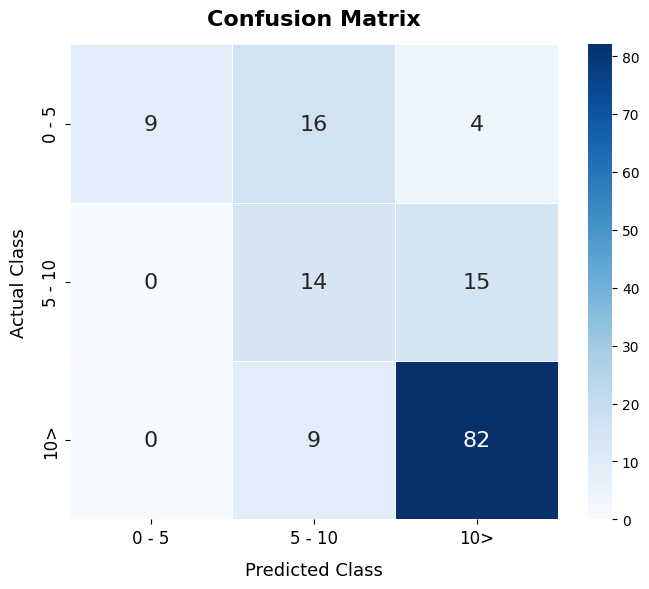

✅ Confusion matrix saved → /content/drive/MyDrive/NeoJaundice/results/confusion_matrix_predictions_dual_RGB_HSV.png


In [ ]:


# =============================================================
# CLASSIFICATION FROM REGRESSION PREDICTIONS
# =============================================================
# What this script does:
#
#  1. Reads the regression predictions CSV (columns must include:
#       patient_id, actual_bilirubin, predicted_bilirubin)
#
#  2. Groups images in sequential batches of 3 rows — the first
#     3 rows = Patient 1, next 3 = Patient 2, and so on.
#     Each group MUST share the same patient_id (validated below).
#
#  3. For each patient group:
#       - Averages the 3 predicted_bilirubin values → mean_pred
#       - Averages the 3 actual_bilirubin values    → mean_actual
#       - Classifies mean_pred  → predicted_class
#       - Classifies mean_actual → actual_class
#
#     Classification bins (per paper):
#       Class 0 → 0–5   mg/dL
#       Class 1 → 5–10  mg/dL
#       Class 2 → >10   mg/dL
#
#  4. Computes 8 evaluation metrics at patient level:
#       Regression  : RMSE, MAE, R²
#       Classification: Accuracy, Precision, Recall, F1 (weighted)
#
#  5. Saves outputs:
#       classification_patient_level.csv  — one row per patient
#       classification_metrics.csv        — the 8 evaluation metrics
# =============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
)

# ─────────────────────────────────────────────────────────────
# CONFIGURATION  ← edit here
# ─────────────────────────────────────────────────────────────

REGRESSION_CSV = "/content/drive/MyDrive/NeoJaundice/results/predictions_dual_RGB_HSV.csv"
# Swap to single-stream if needed:
#REGRESSION_CSV = "/content/drive/MyDrive/NeoJaundice/results/predictions_RGB_single.csv"

OUTPUT_DIR = "/content/drive/MyDrive/NeoJaundice/results"

# Images per patient (3: head, face, chest)
IMAGES_PER_PATIENT = 3

# ─────────────────────────────────────────────────────────────
# CLASS BOUNDARIES  (paper: 0-5, 5-10, >10 mg/dL)
# ─────────────────────────────────────────────────────────────
CLASS_NAMES = ["0–5 mg/dL", "5–10 mg/dL", ">10 mg/dL"]


def plot_confusion_matrix(y_true, y_pred, output_dir, source_name=""):
    """
    Saves a styled confusion matrix plot matching the paper's figure.
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    labels = ["0 - 5", "5 - 10", "10>"]

    fig, ax = plt.subplots(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 16},
        ax=ax,
    )

    ax.set_title("Confusion Matrix", fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("Predicted Class", fontsize=13, labelpad=10)
    ax.set_ylabel("Actual Class",    fontsize=13, labelpad=10)
    ax.tick_params(axis="both", labelsize=12)

    # Rotate tick labels to match the paper's style
    ax.set_xticklabels(labels, rotation=0,  ha="center")
    ax.set_yticklabels(labels, rotation=90, va="center")

    plt.tight_layout()

    plot_path = os.path.join(output_dir, f"confusion_matrix_{source_name}.png")
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Confusion matrix saved → {plot_path}")
    plt.close(fig)


def bilirubin_to_class(value: float) -> int:
    """Map a continuous bilirubin value (mg/dL) → class index."""
    if value < 5:
        return 0
    elif value < 10:
        return 1
    else:
        return 2


# ─────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────

def compute_all_metrics(
    actual_bili:   list,
    pred_bili:     list,
    actual_class:  list,
    pred_class:    list,
    source_name:   str = "",
) -> dict:
    """
    Compute and return all 8 evaluation metrics:
      Regression    → RMSE, MAE, R²
      Classification→ Accuracy, Precision, Recall, F1 (weighted)
    """
    actual_bili  = np.array(actual_bili,  dtype=float)
    pred_bili    = np.array(pred_bili,    dtype=float)
    actual_class = np.array(actual_class, dtype=int)
    pred_class   = np.array(pred_class,   dtype=int)

    # ── Regression metrics ────────────────────────────────────
    mae  = mean_absolute_error(actual_bili, pred_bili)
    rmse = np.sqrt(mean_squared_error(actual_bili, pred_bili))
    r2   = r2_score(actual_bili, pred_bili)

    # ── Classification metrics ────────────────────────────────
    acc  = accuracy_score(actual_class, pred_class) * 100
    prec = precision_score(actual_class, pred_class,
                           average="weighted", zero_division=0) * 100
    rec  = recall_score(actual_class, pred_class,
                        average="weighted", zero_division=0) * 100
    f1   = f1_score(actual_class, pred_class,
                    average="weighted", zero_division=0) * 100

    metrics = {
        "source":    source_name,
        "n_patients": len(actual_bili),
        # Regression
        "RMSE":      round(rmse, 4),
        "MAE":       round(mae,  4),
        "R2":        round(r2,   4),
        # Classification (%)
        "Accuracy":  round(acc,  2),
        "Precision": round(prec, 2),
        "Recall":    round(rec,  2),
        "F1_Score":  round(f1,   2),
    }

    # ── Pretty print ──────────────────────────────────────────
    print(f"\n{'='*54}")
    print(f"  EVALUATION METRICS  ({source_name})")
    print(f"  Patients : {len(actual_bili)}")
    print(f"{'='*54}")
    print(f"  ── Regression ──────────────────────────────────")
    print(f"  RMSE      : {rmse:.4f} mg/dL")
    print(f"  MAE       : {mae:.4f}  mg/dL")
    print(f"  R²        : {r2:.4f}")
    print(f"  ── Classification (weighted avg) ───────────────")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Precision : {prec:.2f}%")
    print(f"  Recall    : {rec:.2f}%")
    print(f"  F1 Score  : {f1:.2f}%")

    # ── Per-class breakdown ───────────────────────────────────
    print(f"\n  Per-class breakdown:")
    print(f"  {'Class':<14} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>10} {'Support':>10}")
    print(f"  {'-'*54}")
    for i, name in enumerate(CLASS_NAMES):
        mask = actual_class == i
        if mask.sum() == 0:
            continue
        p = precision_score(actual_class, pred_class, labels=[i],
                            average="micro", zero_division=0) * 100
        r = recall_score(actual_class, pred_class, labels=[i],
                         average="micro", zero_division=0) * 100
        f = f1_score(actual_class, pred_class, labels=[i],
                     average="micro", zero_division=0) * 100
        print(f"  {name:<14} {p:>9.2f}% {r:>9.2f}% {f:>9.2f}% "
              f"{int(mask.sum()):>10}")

    # ── Confusion matrix ──────────────────────────────────────
    print(f"\n  Confusion Matrix (rows=actual, cols=predicted):")
    cm = confusion_matrix(actual_class, pred_class, labels=[0, 1, 2])
    header = "  {:>12}".format("") + "".join(
        f"{CLASS_NAMES[j]:>13}" for j in range(3))
    print(header)
    for i, row in enumerate(cm):
        print(f"  {CLASS_NAMES[i]:>12}" + "".join(f"{v:>13}" for v in row))
    print()

    return metrics


# ─────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── 0. Mount Drive if needed ─────────────────────────────
    if not os.path.exists(REGRESSION_CSV):
        try:
            from google.colab import drive
            drive.mount("/content/drive", force_remount=True)
        except ImportError:
            pass

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ── 1. Load regression predictions ───────────────────────
    print(f"Loading regression predictions:\n  {REGRESSION_CSV}")
    df = pd.read_csv(REGRESSION_CSV)
    print(f"  Rows: {len(df)}  |  Columns: {list(df.columns)}")

    # Clip negatives — bilirubin cannot be negative
    df["predicted_bilirubin"] = df["predicted_bilirubin"].clip(lower=0.0)

    total_rows = len(df)
    if total_rows % IMAGES_PER_PATIENT != 0:
        raise ValueError(
            f"Total rows ({total_rows}) is not divisible by "
            f"IMAGES_PER_PATIENT ({IMAGES_PER_PATIENT}). "
            "Check your CSV."
        )

    # ── 2. Process in sequential groups of 3 ─────────────────
    print(f"\nProcessing {total_rows} rows → "
          f"{total_rows // IMAGES_PER_PATIENT} patients "
          f"({IMAGES_PER_PATIENT} images each) …")

    patient_records = []

    for start in range(0, total_rows, IMAGES_PER_PATIENT):
        group = df.iloc[start : start + IMAGES_PER_PATIENT]

        # ── Validate all rows share the same patient_id ───────
        patient_ids_in_group = group["patient_id"].unique()
        if len(patient_ids_in_group) != 1:
            raise ValueError(
                f"Rows {start}–{start + IMAGES_PER_PATIENT - 1} have "
                f"mixed patient IDs: {patient_ids_in_group.tolist()}. "
                "Ensure the CSV is sorted by patient_id."
            )
        pid = patient_ids_in_group[0]

        # ── Average bilirubin values across the 3 images ─────
        mean_actual = group["actual_bilirubin"].mean()
        mean_pred   = group["predicted_bilirubin"].mean()

        # ── Classify the averaged values ──────────────────────
        actual_cls  = bilirubin_to_class(mean_actual)
        pred_cls    = bilirubin_to_class(mean_pred)

        # ── Individual image predictions (for transparency) ───
        img_actuals = group["actual_bilirubin"].tolist()
        img_preds   = group["predicted_bilirubin"].tolist()
        img_names   = (group["image_name"].tolist()
                       if "image_name" in group.columns else ["N/A"] * 3)

        patient_records.append({
            "patient_id":              pid,
            "image_row_start":         start,          # which rows were used
            "n_images":                len(group),
            # ── Averaged bilirubin ────────────────────────────
            "actual_bilirubin_mean":   round(mean_actual, 4),
            "pred_bilirubin_mean":     round(mean_pred,   4),
            # ── Classification ────────────────────────────────
            "actual_class":            actual_cls,
            "actual_class_name":       CLASS_NAMES[actual_cls],
            "predicted_class":         pred_cls,
            "predicted_class_name":    CLASS_NAMES[pred_cls],
            "patient_correct":         actual_cls == pred_cls,
            # ── Raw image values (transparency) ───────────────
            "image_names":             str(img_names),
            "image_actual_bili":       str([round(v, 4) for v in img_actuals]),
            "image_pred_bili":         str([round(v, 4) for v in img_preds]),
        })

    patient_df = pd.DataFrame(patient_records)

    # ── 3. Compute all 8 metrics ──────────────────────────────
    source_name = os.path.basename(REGRESSION_CSV).replace(".csv", "")

    metrics = compute_all_metrics(
        actual_bili  = patient_df["actual_bilirubin_mean"].tolist(),
        pred_bili    = patient_df["pred_bilirubin_mean"].tolist(),
        actual_class = patient_df["actual_class"].tolist(),
        pred_class   = patient_df["predicted_class"].tolist(),
        source_name  = source_name,
    )

    # ── 4. Summary counts ─────────────────────────────────────
    correct = patient_df["patient_correct"].sum()
    total   = len(patient_df)
    print(f"  Patients: {total} total, {correct} correct "
          f"({correct/total*100:.2f}%)")
    print(f"\n  Class distribution (actual, patient level):")
    for i, name in enumerate(CLASS_NAMES):
        n = (patient_df["actual_class"] == i).sum()
        print(f"    {name}: {n} patients")

    # ── 5. Save patient-level CSV ─────────────────────────────
    pat_csv_path = os.path.join(OUTPUT_DIR, "classification_patient_level.csv")
    patient_df.to_csv(pat_csv_path, index=False)
    print(f"\n✅ Patient-level CSV saved → {pat_csv_path}")

    # ── 6. Save evaluation metrics CSV ───────────────────────
    metrics_path = os.path.join(OUTPUT_DIR, "classification_metrics.csv")
    metrics_df   = pd.DataFrame([metrics])

    # Append to existing file so you can compare multiple runs
    if os.path.exists(metrics_path):
        existing   = pd.read_csv(metrics_path)
        metrics_df = pd.concat([existing, metrics_df], ignore_index=True)

    metrics_df.to_csv(metrics_path, index=False)
    print(f"✅ Metrics CSV saved        → {metrics_path}")

    # ── 7. Sample output ──────────────────────────────────────
    print(f"\n── Sample: first 5 patient-level results ───────────")
    print(patient_df[[
        "patient_id", "image_row_start",
        "actual_bilirubin_mean", "pred_bilirubin_mean",
        "actual_class_name", "predicted_class_name", "patient_correct",
    ]].head(5).to_string(index=False))

# Add this:
plot_confusion_matrix(
    y_true       = patient_df["actual_class"].tolist(),
    y_pred       = patient_df["predicted_class"].tolist(),
    output_dir   = OUTPUT_DIR,
    source_name  = source_name,   # uses the CSV filename as the plot filename
)
